# Sales & Revenue Analytics Using Python, SQL and Excel

## Project Overview

This project analyzes retail sales transaction data to identify revenue trends, top-performing products, geographic sales patterns, and key business insights using Python, SQL, and Excel.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('Updated_sales.csv')
df.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001"
1,NaN,NaN,NaN,NaN,NaN,NaN
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215"
3,176560,Google Phone,1,600,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"


In [4]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Shape: (30394, 6)

Columns:
['Order ID', 'Product', 'Quantity Ordered', 'Price Each', 'Order Date', 'Purchase Address']

Data Types:
Order ID            object
Product             object
Quantity Ordered    object
Price Each          object
Order Date          object
Purchase Address    object
dtype: object


In [5]:
df.describe(include='all')

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
count,30307,30307,30307,30307,30307,30307
unique,29019,20,9,24,23316,27854
top,Order ID,Lightning Charging Cable,1,14.95,Order Date,Purchase Address
freq,61,3556,27405,3556,61,61


In [6]:
df.isnull().sum()

Order ID            87
Product             87
Quantity Ordered    87
Price Each          87
Order Date          87
Purchase Address    87
dtype: int64

In [7]:
df.isnull().mean() * 100

Order ID            0.286241
Product             0.286241
Quantity Ordered    0.286241
Price Each          0.286241
Order Date          0.286241
Purchase Address    0.286241
dtype: float64

## Data Cleaning

The dataset contains 87 incomplete transaction records, representing approximately 0.29% of the dataset. Since these records have missing values across transaction fields, they are removed before further analysis.

In [8]:
df = df.dropna()

print("Shape after removing missing values:", df.shape)

Shape after removing missing values: (30307, 6)


In [9]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 100


In [10]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (30207, 6)


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30207 entries, 0 to 30393
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Order ID          30207 non-null  object
 1   Product           30207 non-null  object
 2   Quantity Ordered  30207 non-null  object
 3   Price Each        30207 non-null  object
 4   Order Date        30207 non-null  object
 5   Purchase Address  30207 non-null  object
dtypes: object(6)
memory usage: 1.6+ MB


In [12]:
print("Unique orders:", df['Order ID'].nunique())
print("Unique products:", df['Product'].nunique())

Unique orders: 29019
Unique products: 20


In [13]:
df['Product'].value_counts()

Product
Lightning Charging Cable      3547
AA Batteries (4-pack)         3418
USB-C Charging Cable          3414
AAA Batteries (4-pack)        3325
Wired Headphones              3079
Apple Airpods Headphones      2512
Bose SoundSport Headphones    2148
27in FHD Monitor              1219
iPhone                        1131
34in Ultrawide Monitor        1028
27in 4K Gaming Monitor         999
Google Phone                   939
Flatscreen TV                  788
Macbook Pro Laptop             751
ThinkPad Laptop                667
20in Monitor                   648
Vareebadd Phone                361
LG Dryer                       123
LG Washing Machine             109
Product                          1
Name: count, dtype: int64

In [14]:
df[df['Product'] == 'Product']

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
519,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address


In [15]:
df = df[df['Product'] != 'Product'].copy()

In [16]:
df['Quantity Ordered'] = pd.to_numeric(df['Quantity Ordered'])

In [17]:
df['Price Each'] = pd.to_numeric(df['Price Each'])

In [18]:
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')

C:\Users\aryan\AppData\Local\Temp\ipykernel_23032\3876843441.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30206 entries, 0 to 30393
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order ID          30206 non-null  object        
 1   Product           30206 non-null  object        
 2   Quantity Ordered  30206 non-null  int64         
 3   Price Each        30206 non-null  float64       
 4   Order Date        30206 non-null  datetime64[ns]
 5   Purchase Address  30206 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(3)
memory usage: 1.6+ MB


In [20]:
print("Final shape:", df.shape)
print("Missing values:")
print(df.isnull().sum())

Final shape: (30206, 6)
Missing values:
Order ID            0
Product             0
Quantity Ordered    0
Price Each          0
Order Date          0
Purchase Address    0
dtype: int64


In [21]:
df['Revenue'] = df['Quantity Ordered'] * df['Price Each']

In [22]:
df[['Product', 'Quantity Ordered', 'Price Each', 'Revenue']].head()

,Product,Quantity Ordered,Price Each,Revenue
0,USB-C Charging Cable,2,11.95,23.90
2,Bose SoundSport Headphones,1,99.99,99.99
3,Google Phone,1,600.00,600.00
4,Wired Headphones,1,11.99,11.99
5,Wired Headphones,1,11.99,11.99


In [23]:
df['Month'] = df['Order Date'].dt.month

In [24]:
df['Hour'] = df['Order Date'].dt.hour

In [25]:
df['City'] = df['Purchase Address'].str.split(',').str[1].str.strip()

In [26]:
df['City'].value_counts()

City
San Francisco    7262
Los Angeles      4884
New York City    4052
Boston           3159
Seattle          2445
Atlanta          2411
Dallas           2315
Portland         2057
Austin           1621
Name: count, dtype: int64

In [27]:
df['Year'] = df['Order Date'].dt.year

In [28]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df.head()

Shape: (30206, 11)

Columns:
['Order ID', 'Product', 'Quantity Ordered', 'Price Each', 'Order Date', 'Purchase Address', 'Revenue', 'Month', 'Hour', 'City', 'Year']


,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Revenue,Month,Hour,City,Year
0,176558,USB-C Charging Cable,2,11.95,2019-04-19 08:46:00,"917 1st St, Dallas, TX 75001",23.90,4,8,Dallas,2019
2,176559,Bose SoundSport Headphones,1,99.99,2019-04-07 22:30:00,"682 Chestnut St, Boston, MA 02215",99.99,4,22,Boston,2019
3,176560,Google Phone,1,600.00,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",600.00,4,14,Los Angeles,2019
4,176560,Wired Headphones,1,11.99,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",11.99,4,14,Los Angeles,2019
5,176561,Wired Headphones,1,11.99,2019-04-30 09:27:00,"333 8th St, Los Angeles, CA 90001",11.99,4,9,Los Angeles,2019


## Business Performance Analysis

Key business performance indicators are calculated to understand overall revenue, sales volume, order value, and transaction performance.

In [29]:
total_revenue = df['Revenue'].sum()
print(f"Total Revenue: ${total_revenue:,.2f}")

Total Revenue: $5,635,634.65


In [30]:
total_units = df['Quantity Ordered'].sum()
print(f"Total Units Sold: {total_units:,}")

Total Units Sold: 33,969


In [31]:
avg_transaction = df['Revenue'].mean()
print(f"Average Transaction Value: ${avg_transaction:,.2f}")

Average Transaction Value: $186.57


In [32]:
unique_orders = df['Order ID'].nunique()
print(f"Unique Orders: {unique_orders:,}")

Unique Orders: 29,018


In [33]:
avg_order_value = total_revenue / unique_orders
print(f"Average Order Value: ${avg_order_value:,.2f}")

Average Order Value: $194.21


In [34]:
kpi_summary = pd.DataFrame({
    'KPI': [
        'Total Revenue',
        'Total Units Sold',
        'Unique Orders',
        'Average Order Value',
        'Average Transaction Value'
    ],
    'Value': [
        total_revenue,
        total_units,
        unique_orders,
        avg_order_value,
        avg_transaction
    ]
})

kpi_summary

,KPI,Value
0,Total Revenue,5.635635e+06
1,Total Units Sold,3.396900e+04
2,Unique Orders,2.901800e+04
3,Average Order Value,1.942117e+02
4,Average Transaction Value,1.865734e+02


## Monthly Sales Analysis

Monthly revenue and sales volume are analyzed to identify seasonal patterns, peak-performing months, and changes in customer purchasing activity.

In [35]:
monthly_revenue = df.groupby('Month')['Revenue'].sum()
monthly_revenue

Month
4    3384047.56
5      10559.29
8    2238931.06
9       2096.74
Name: Revenue, dtype: float64

In [36]:
monthly_units = df.groupby('Month')['Quantity Ordered'].sum()
monthly_units

Month
4    20517
5       29
8    13411
9       12
Name: Quantity Ordered, dtype: int64

In [37]:
monthly_summary = pd.DataFrame({
    'Revenue': monthly_revenue,
    'Units Sold': monthly_units
})

monthly_summary

,Revenue,Units Sold
Month,,
4,3384047.56,20517
5,10559.29,29
8,2238931.06,13411
9,2096.74,12


In [38]:
best_month = monthly_summary['Revenue'].idxmax()
best_month_revenue = monthly_summary['Revenue'].max()

print(f"Highest Revenue Month: {best_month}")
print(f"Revenue: ${best_month_revenue:,.2f}")

Highest Revenue Month: 4
Revenue: $3,384,047.56


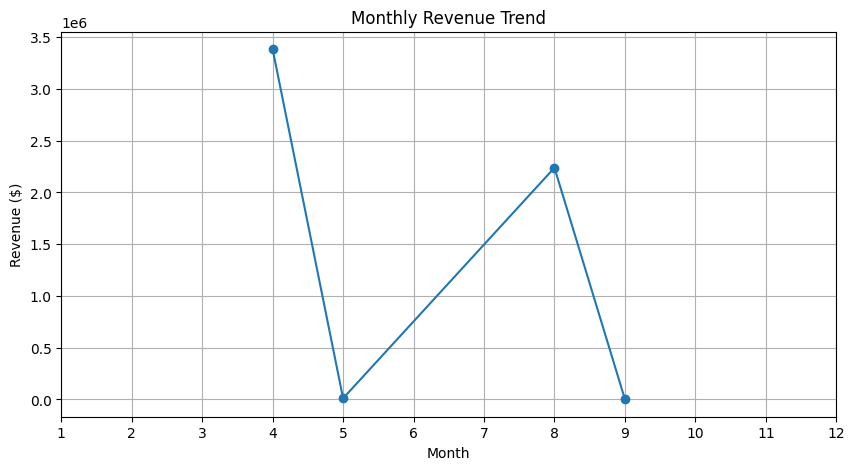

In [39]:
plt.figure(figsize=(10,5))

plt.plot(monthly_summary.index, monthly_summary['Revenue'], marker='o')

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue ($)')
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()

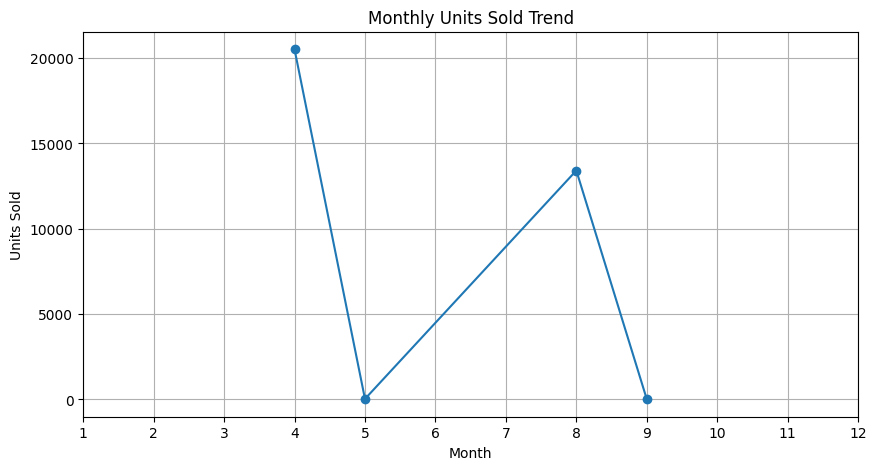

In [40]:
plt.figure(figsize=(10,5))

plt.plot(monthly_summary.index, monthly_summary['Units Sold'], marker='o')

plt.title('Monthly Units Sold Trend')
plt.xlabel('Month')
plt.ylabel('Units Sold')
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()

## Product Performance Analysis

Product-level analysis is performed to identify the best-selling products, highest-revenue products, and products contributing most to overall sales.

In [41]:
product_units = df.groupby('Product')['Quantity Ordered'].sum().sort_values(ascending=False)
product_units

Product
AAA Batteries (4-pack)        4950
AA Batteries (4-pack)         4647
Lightning Charging Cable      3803
USB-C Charging Cable          3723
Wired Headphones              3353
Apple Airpods Headphones      2532
Bose SoundSport Headphones    2165
27in FHD Monitor              1228
iPhone                        1133
34in Ultrawide Monitor        1031
27in 4K Gaming Monitor        1003
Google Phone                   941
Flatscreen TV                  789
Macbook Pro Laptop             753
ThinkPad Laptop                667
20in Monitor                   656
Vareebadd Phone                363
LG Dryer                       123
LG Washing Machine             109
Name: Quantity Ordered, dtype: int64

In [42]:
product_revenue = df.groupby('Product')['Revenue'].sum().sort_values(ascending=False)
product_revenue

Product
Macbook Pro Laptop            1280100.00
iPhone                         793100.00
ThinkPad Laptop                666993.33
Google Phone                   564600.00
34in Ultrawide Monitor         391769.69
27in 4K Gaming Monitor         391159.97
Apple Airpods Headphones       379800.00
Flatscreen TV                  236700.00
Bose SoundSport Headphones     216478.35
27in FHD Monitor               184187.72
Vareebadd Phone                145200.00
LG Dryer                        73800.00
20in Monitor                    72153.44
LG Washing Machine              65400.00
Lightning Charging Cable        56854.85
USB-C Charging Cable            44489.85
Wired Headphones                40202.47
AA Batteries (4-pack)           17844.48
AAA Batteries (4-pack)          14800.50
Name: Revenue, dtype: float64

In [43]:
product_summary = pd.DataFrame({
    'Units Sold': product_units,
    'Revenue': product_revenue
})

product_summary

,Units Sold,Revenue
Product,,
20in Monitor,656,72153.44
27in 4K Gaming Monitor,1003,391159.97
27in FHD Monitor,1228,184187.72
34in Ultrawide Monitor,1031,391769.69
AA Batteries (4-pack),4647,17844.48
AAA Batteries (4-pack),4950,14800.50
Apple Airpods Headphones,2532,379800.00
Bose SoundSport Headphones,2165,216478.35
Flatscreen TV,789,236700.00


In [44]:
top_product = product_units.idxmax()
top_product_units = product_units.max()

print(f"Top-Selling Product: {top_product}")
print(f"Units Sold: {top_product_units:,}")

Top-Selling Product: AAA Batteries (4-pack)
Units Sold: 4,950


In [45]:
top_revenue_product = product_revenue.idxmax()
top_revenue = product_revenue.max()

print(f"Highest-Revenue Product: {top_revenue_product}")
print(f"Revenue: ${top_revenue:,.2f}")

Highest-Revenue Product: Macbook Pro Laptop
Revenue: $1,280,100.00


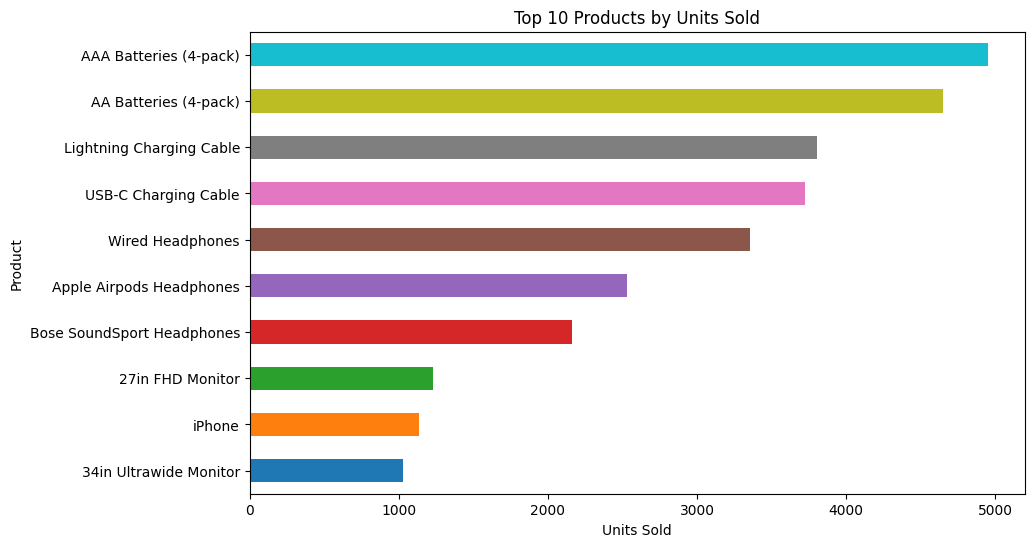

In [47]:
plt.figure(figsize=(10,6))

product_units.head(10).sort_values().plot(
    kind='barh',
    color=plt.cm.tab10(range(10))
)

plt.title('Top 10 Products by Units Sold')
plt.xlabel('Units Sold')
plt.ylabel('Product')
plt.show()

## Product Revenue Contribution

Revenue contribution is analyzed to identify which products generate the largest share of total sales and to distinguish high-volume products from high-value products.

In [48]:
product_summary['Revenue %'] = (
    product_summary['Revenue'] / total_revenue * 100
)

In [49]:
product_summary = product_summary.sort_values(
    'Revenue',
    ascending=False
)

product_summary

,Units Sold,Revenue,Revenue %
Product,,,
Macbook Pro Laptop,753,1280100.00,22.714389
iPhone,1133,793100.00,14.072949
ThinkPad Laptop,667,666993.33,11.835283
Google Phone,941,564600.00,10.018393
34in Ultrawide Monitor,1031,391769.69,6.951652
27in 4K Gaming Monitor,1003,391159.97,6.940833
Apple Airpods Headphones,2532,379800.00,6.739259
Flatscreen TV,789,236700.00,4.200059
Bose SoundSport Headphones,2165,216478.35,3.841242


In [50]:
product_summary.head(10)

,Units Sold,Revenue,Revenue %
Product,,,
Macbook Pro Laptop,753,1280100.00,22.714389
iPhone,1133,793100.00,14.072949
ThinkPad Laptop,667,666993.33,11.835283
Google Phone,941,564600.00,10.018393
34in Ultrawide Monitor,1031,391769.69,6.951652
27in 4K Gaming Monitor,1003,391159.97,6.940833
Apple Airpods Headphones,2532,379800.00,6.739259
Flatscreen TV,789,236700.00,4.200059
Bose SoundSport Headphones,2165,216478.35,3.841242


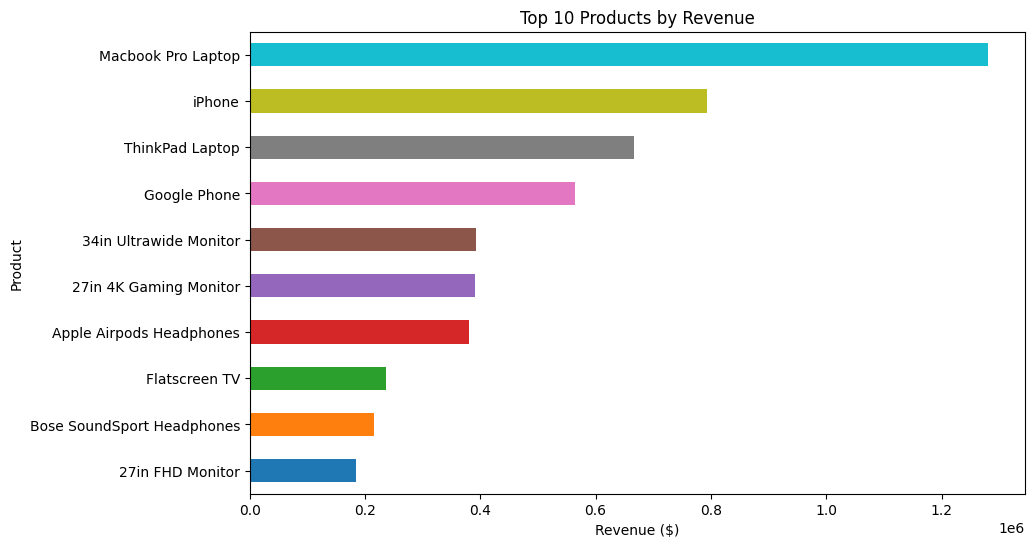

In [51]:
plt.figure(figsize=(10,6))

product_summary.head(10).sort_values('Revenue')['Revenue'].plot(
    kind='barh',
    color=plt.cm.tab10(range(10))
)

plt.title('Top 10 Products by Revenue')
plt.xlabel('Revenue ($)')
plt.ylabel('Product')
plt.show()

In [52]:
top_5_revenue_share = product_summary.head(5)['Revenue %'].sum()

print(f"Top 5 products contribute {top_5_revenue_share:.2f}% of total revenue")

Top 5 products contribute 65.59% of total revenue


In [53]:
product_summary.head(5)[['Units Sold', 'Revenue', 'Revenue %']]

,Units Sold,Revenue,Revenue %
Product,,,
Macbook Pro Laptop,753,1280100.00,22.714389
iPhone,1133,793100.00,14.072949
ThinkPad Laptop,667,666993.33,11.835283
Google Phone,941,564600.00,10.018393
34in Ultrawide Monitor,1031,391769.69,6.951652


## Geographic Sales Analysis

Sales performance is analyzed across cities to identify major revenue-generating markets and differences in customer demand across locations.

In [54]:
city_revenue = df.groupby('City')['Revenue'].sum().sort_values(ascending=False)
city_revenue

City
San Francisco    1355726.22
Los Angeles       894947.08
New York City     748830.79
Boston            593725.52
Seattle           464830.30
Atlanta           453695.68
Dallas            432379.00
Portland          393252.85
Austin            298247.21
Name: Revenue, dtype: float64

In [55]:
city_units = df.groupby('City')['Quantity Ordered'].sum().sort_values(ascending=False)
city_units

City
San Francisco    8171
Los Angeles      5461
New York City    4537
Boston           3595
Seattle          2753
Atlanta          2684
Dallas           2618
Portland         2324
Austin           1826
Name: Quantity Ordered, dtype: int64

In [56]:
city_summary = pd.DataFrame({
    'Revenue': city_revenue,
    'Units Sold': city_units
})

city_summary

,Revenue,Units Sold
City,,
San Francisco,1355726.22,8171
Los Angeles,894947.08,5461
New York City,748830.79,4537
Boston,593725.52,3595
Seattle,464830.30,2753
Atlanta,453695.68,2684
Dallas,432379.00,2618
Portland,393252.85,2324
Austin,298247.21,1826


In [57]:
top_city = city_revenue.idxmax()
top_city_revenue = city_revenue.max()

print(f"Highest-Revenue City: {top_city}")
print(f"Revenue: ${top_city_revenue:,.2f}")

Highest-Revenue City: San Francisco
Revenue: $1,355,726.22


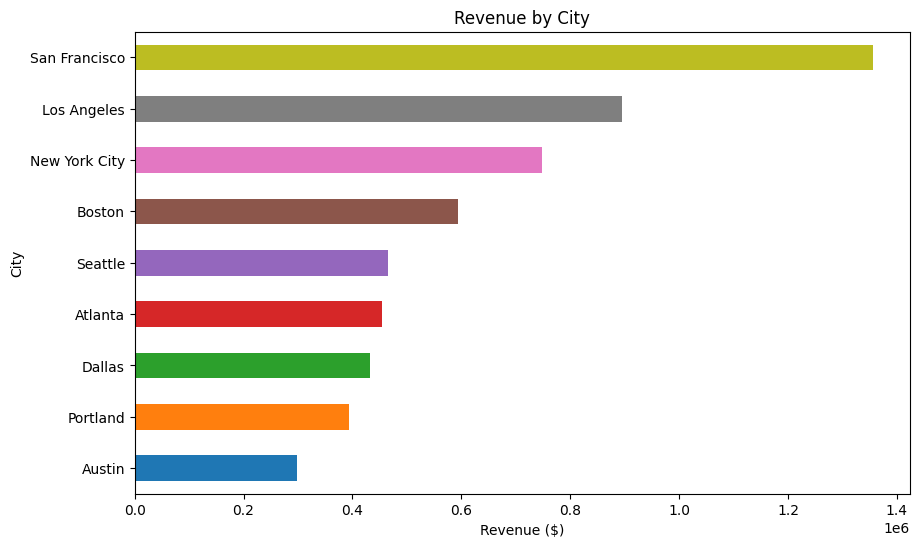

In [58]:
plt.figure(figsize=(10,6))

city_revenue.sort_values().plot(
    kind='barh',
    color=plt.cm.tab10(range(len(city_revenue)))
)

plt.title('Revenue by City')
plt.xlabel('Revenue ($)')
plt.ylabel('City')
plt.show()

In [59]:
city_summary.head(5)

,Revenue,Units Sold
City,,
San Francisco,1355726.22,8171
Los Angeles,894947.08,5461
New York City,748830.79,4537
Boston,593725.52,3595
Seattle,464830.30,2753


## Peak Sales Hour Analysis

Hourly sales activity is analyzed to identify periods of high customer purchasing activity and determine the most active sales hours.

In [60]:
hourly_revenue = df.groupby('Hour')['Revenue'].sum().sort_values(ascending=False)
hourly_revenue

Hour
19    406385.10
12    393235.47
11    368741.69
20    368546.99
18    355167.85
14    354712.36
13    337105.06
21    328738.61
10    326772.57
17    322301.61
15    321674.54
16    318019.07
9     269219.95
22    260242.32
8     199843.04
23    179664.11
7     122792.95
0     111933.62
6      79435.56
1      72260.42
2      38074.71
3      35823.19
5      35759.47
4      29184.39
Name: Revenue, dtype: float64

In [61]:
hourly_units = df.groupby('Hour')['Quantity Ordered'].sum().sort_values(ascending=False)
hourly_units

Hour
19    2351
11    2259
20    2259
12    2235
18    2228
13    2210
14    2058
10    2037
16    1933
15    1913
21    1909
17    1876
22    1614
9     1577
8     1182
23    1123
7      751
0      718
6      495
1      427
5      276
2      238
4      150
3      150
Name: Quantity Ordered, dtype: int64

In [62]:
peak_hour = hourly_revenue.idxmax()
peak_hour_revenue = hourly_revenue.max()

print(f"Peak Revenue Hour: {peak_hour}:00")
print(f"Revenue: ${peak_hour_revenue:,.2f}")

Peak Revenue Hour: 19:00
Revenue: $406,385.10


In [63]:
peak_volume_hour = hourly_units.idxmax()
peak_volume = hourly_units.max()

print(f"Peak Sales Volume Hour: {peak_volume_hour}:00")
print(f"Units Sold: {peak_volume:,}")

Peak Sales Volume Hour: 19:00
Units Sold: 2,351


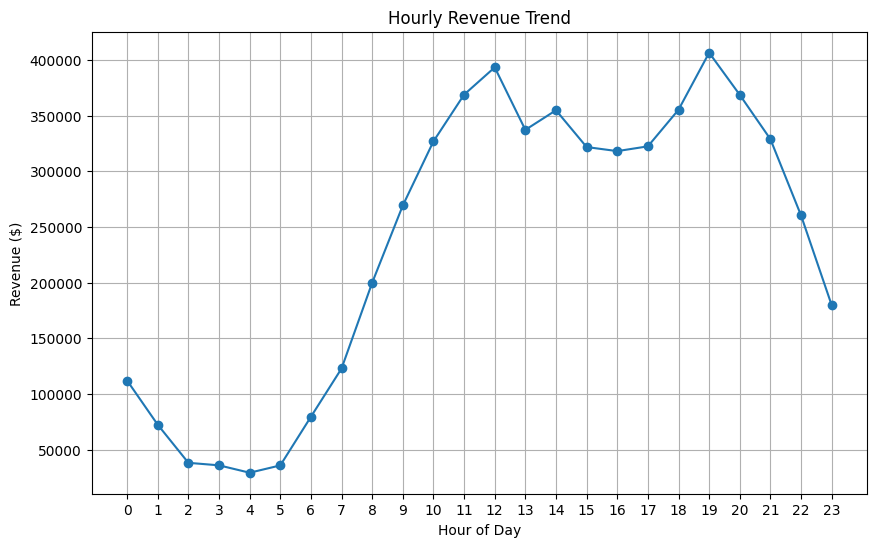

In [64]:
plt.figure(figsize=(10,6))

hourly_revenue.sort_index().plot(
    kind='line',
    marker='o'
)

plt.title('Hourly Revenue Trend')
plt.xlabel('Hour of Day')
plt.ylabel('Revenue ($)')
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()

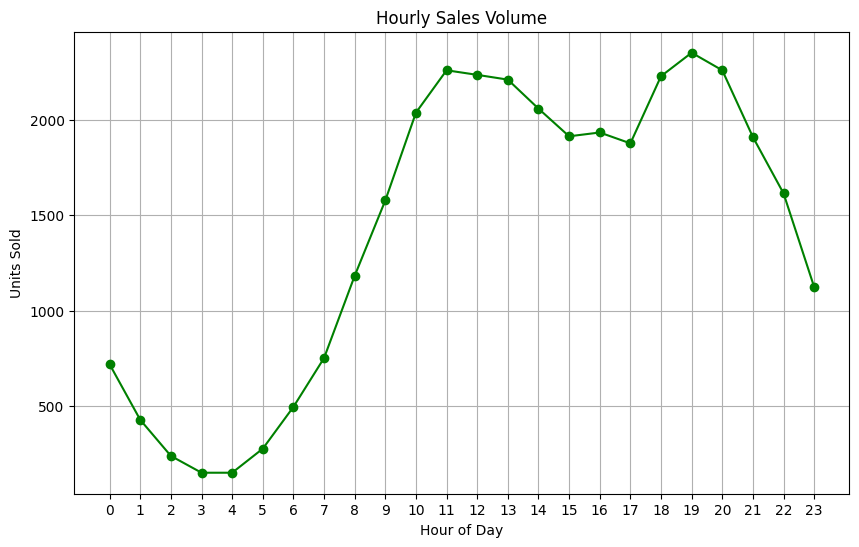

In [66]:
plt.figure(figsize=(10,6))

hourly_units.sort_index().plot(
    kind='line',
    marker='o',
    color='green'
)

plt.title('Hourly Sales Volume')
plt.xlabel('Hour of Day')
plt.ylabel('Units Sold')
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()

### Key Insight

The analysis shows that 19:00 (7 PM) is the peak sales hour, generating the highest revenue of $406,385.10 and the highest sales volume of 2,351 units. This indicates that customer purchasing activity is strongest during the evening period.

## Product Combination Analysis

Product combination analysis identifies products that are frequently purchased together within the same order. These insights can help identify cross-selling opportunities and support product bundling strategies.

In [67]:
order_products = df[['Order ID', 'Product']].drop_duplicates()
order_products.head()

,Order ID,Product
0,176558,USB-C Charging Cable
2,176559,Bose SoundSport Headphones
3,176560,Google Phone
4,176560,Wired Headphones
5,176561,Wired Headphones


In [68]:
from itertools import combinations
from collections import Counter

pair_counts = Counter()

for order_id, group in order_products.groupby('Order ID'):
    products = sorted(group['Product'].unique())
    
    for pair in combinations(products, 2):
        pair_counts[pair] += 1

In [69]:
pair_summary = pd.DataFrame(
    pair_counts.items(),
    columns=['Product Pair', 'Orders Together']
)

pair_summary = pair_summary.sort_values(
    'Orders Together',
    ascending=False
)

pair_summary.head(10)

,Product Pair,Orders Together
7,"(Lightning Charging Cable, iPhone)",172
1,"(Google Phone, USB-C Charging Cable)",166
12,"(Wired Headphones, iPhone)",67
0,"(Google Phone, Wired Headphones)",65
17,"(Apple Airpods Headphones, iPhone)",64
21,"(USB-C Charging Cable, Vareebadd Phone)",61
8,"(Bose SoundSport Headphones, Google Phone)",36
32,"(USB-C Charging Cable, Wired Headphones)",28
37,"(AA Batteries (4-pack), Lightning Charging Cable)",25
39,"(Vareebadd Phone, Wired Headphones)",22


In [70]:
pair_summary.head(10).reset_index(drop=True)

,Product Pair,Orders Together
0,"(Lightning Charging Cable, iPhone)",172
1,"(Google Phone, USB-C Charging Cable)",166
2,"(Wired Headphones, iPhone)",67
3,"(Google Phone, Wired Headphones)",65
4,"(Apple Airpods Headphones, iPhone)",64
5,"(USB-C Charging Cable, Vareebadd Phone)",61
6,"(Bose SoundSport Headphones, Google Phone)",36
7,"(USB-C Charging Cable, Wired Headphones)",28
8,"(AA Batteries (4-pack), Lightning Charging Cable)",25
9,"(Vareebadd Phone, Wired Headphones)",22


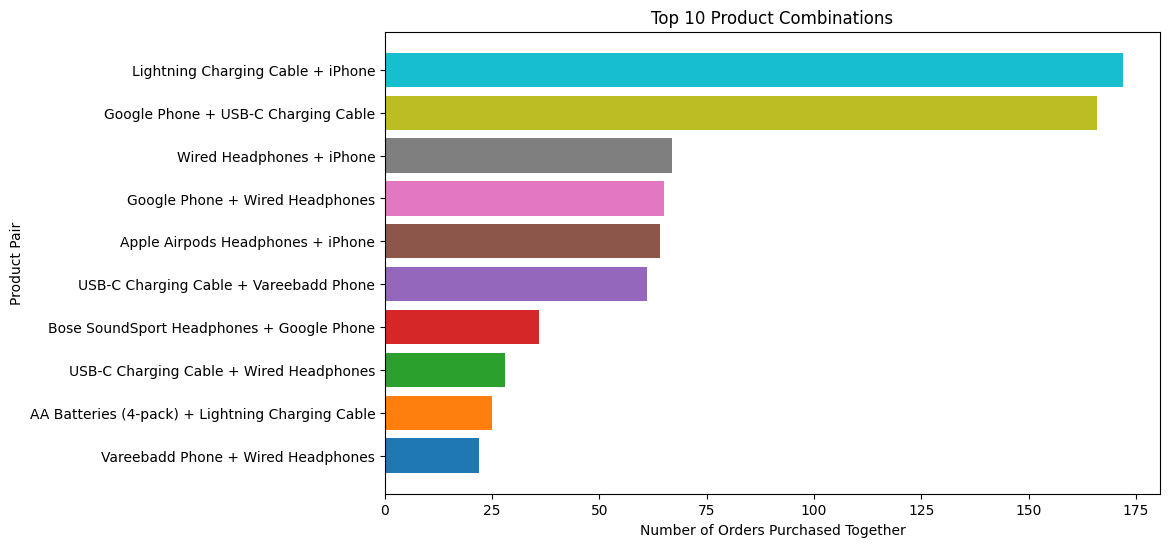

In [73]:
top_pairs = pair_summary.head(10).copy()

top_pairs['Pair'] = top_pairs['Product Pair'].apply(
    lambda x: ' + '.join(x)
)

plt.figure(figsize=(10,6))

plt.barh(
    top_pairs['Pair'][::-1],
    top_pairs['Orders Together'][::-1],
    color=plt.cm.tab10(range(10))
)

plt.title('Top 10 Product Combinations')
plt.xlabel('Number of Orders Purchased Together')
plt.ylabel('Product Pair')
plt.show()

In [72]:
top_pair = pair_summary.iloc[0]

print("Most Common Product Combination:", top_pair['Product Pair'])
print("Orders Together:", top_pair['Orders Together'])

Most Common Product Combination: ('Lightning Charging Cable', 'iPhone')
Orders Together: 172


### Key Insight

The most frequently purchased product combination is the Lightning Charging Cable and iPhone, appearing together in 172 orders, followed by Google Phone and USB-C Charging Cable with 166 orders. These combinations indicate potential cross-selling and product bundling opportunities.

## SQL Business Analysis

SQL queries are used to analyze the cleaned sales data and answer key business questions related to revenue, product performance, sales volume, and geographic performance.

In [74]:
import sqlite3

In [75]:
conn = sqlite3.connect('sales_analysis.db')

In [76]:
df.to_sql('sales', conn, if_exists='replace', index=False)

print("Data loaded into SQL table successfully.")

Data loaded into SQL table successfully.


In [77]:
query = """
SELECT *
FROM sales
LIMIT 5;
"""

pd.read_sql_query(query, conn)

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Revenue,Month,Hour,City,Year
0,176558,USB-C Charging Cable,2,11.95,2019-04-19 08:46:00,"917 1st St, Dallas, TX 75001",23.90,4,8,Dallas,2019
1,176559,Bose SoundSport Headphones,1,99.99,2019-04-07 22:30:00,"682 Chestnut St, Boston, MA 02215",99.99,4,22,Boston,2019
2,176560,Google Phone,1,600.00,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",600.00,4,14,Los Angeles,2019
3,176560,Wired Headphones,1,11.99,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",11.99,4,14,Los Angeles,2019
4,176561,Wired Headphones,1,11.99,2019-04-30 09:27:00,"333 8th St, Los Angeles, CA 90001",11.99,4,9,Los Angeles,2019


In [79]:
query = """
SELECT COUNT(*) AS total_records
FROM sales;
"""

pd.read_sql_query(query, conn)

,total_records
0,30206


In [80]:
query = """
SELECT ROUND(SUM(Revenue), 2) AS total_revenue
FROM sales;
"""

pd.read_sql_query(query, conn)

,total_revenue
0,5635634.65


In [81]:
query = """
SELECT SUM("Quantity Ordered") AS total_units_sold
FROM sales;
"""

pd.read_sql_query(query, conn)

,total_units_sold
0,33969


In [82]:
query = """
SELECT COUNT(DISTINCT "Order ID") AS unique_orders
FROM sales;
"""

pd.read_sql_query(query, conn)

,unique_orders
0,29018


In [83]:
query = """
SELECT ROUND(AVG(Revenue), 2) AS average_transaction_value
FROM sales;
"""

pd.read_sql_query(query, conn)

,average_transaction_value
0,186.57


In [84]:
query = """
SELECT
    Product,
    ROUND(SUM(Revenue), 2) AS total_revenue
FROM sales
GROUP BY Product
ORDER BY total_revenue DESC;
"""

pd.read_sql_query(query, conn)

,Product,total_revenue
0,Macbook Pro Laptop,1280100.00
1,iPhone,793100.00
2,ThinkPad Laptop,666993.33
3,Google Phone,564600.00
4,34in Ultrawide Monitor,391769.69
5,27in 4K Gaming Monitor,391159.97
6,Apple Airpods Headphones,379800.00
7,Flatscreen TV,236700.00
8,Bose SoundSport Headphones,216478.35
9,27in FHD Monitor,184187.72


### SQL Analysis Insight

SQL analysis confirms that the MacBook Pro Laptop generates the highest revenue at $1,280,100, followed by the iPhone and ThinkPad Laptop. The results are consistent with the Python-based product analysis, validating the business findings across both analytical approaches.

In [85]:
query = """
SELECT
    Product,
    SUM("Quantity Ordered") AS units_sold
FROM sales
GROUP BY Product
ORDER BY units_sold DESC;
"""

pd.read_sql_query(query, conn)

,Product,units_sold
0,AAA Batteries (4-pack),4950
1,AA Batteries (4-pack),4647
2,Lightning Charging Cable,3803
3,USB-C Charging Cable,3723
4,Wired Headphones,3353
5,Apple Airpods Headphones,2532
6,Bose SoundSport Headphones,2165
7,27in FHD Monitor,1228
8,iPhone,1133
9,34in Ultrawide Monitor,1031


In [86]:
query = """
SELECT
    City,
    ROUND(SUM(Revenue), 2) AS total_revenue
FROM sales
GROUP BY City
ORDER BY total_revenue DESC;
"""

pd.read_sql_query(query, conn)

,City,total_revenue
0,San Francisco,1355726.22
1,Los Angeles,894947.08
2,New York City,748830.79
3,Boston,593725.52
4,Seattle,464830.30
5,Atlanta,453695.68
6,Dallas,432379.00
7,Portland,393252.85
8,Austin,298247.21


In [87]:
query = """
SELECT
    Year,
    Month,
    ROUND(SUM(Revenue), 2) AS monthly_revenue
FROM sales
GROUP BY Year, Month
ORDER BY Year, Month;
"""

pd.read_sql_query(query, conn)

,Year,Month,monthly_revenue
0,2019,4,3384047.56
1,2019,5,10559.29
2,2019,8,2238931.06
3,2019,9,2096.74


In [88]:
query = """
SELECT
    Hour,
    ROUND(SUM(Revenue), 2) AS hourly_revenue
FROM sales
GROUP BY Hour
ORDER BY hourly_revenue DESC;
"""

pd.read_sql_query(query, conn)

,Hour,hourly_revenue
0,19,406385.10
1,12,393235.47
2,11,368741.69
3,20,368546.99
4,18,355167.85
5,14,354712.36
6,13,337105.06
7,21,328738.61
8,10,326772.57
9,17,322301.61


In [89]:
query = """
SELECT
    City,
    ROUND(SUM(Revenue) / COUNT(DISTINCT "Order ID"), 2) AS average_order_value
FROM sales
GROUP BY City
ORDER BY average_order_value DESC;
"""

pd.read_sql_query(query, conn)

,City,average_order_value
0,Portland,198.91
1,Seattle,197.72
2,Boston,196.60
3,Atlanta,196.49
4,Dallas,195.12
5,San Francisco,193.59
6,Austin,193.04
7,New York City,192.60
8,Los Angeles,190.05


### SQL Analysis Insight

SQL analysis confirms that San Francisco is the highest-revenue city, while Portland has the highest average order value. Revenue peaks at 19:00 (7 PM), consistent with the earlier Python analysis. Among the available months, April 2019 records the highest revenue. These results demonstrate how SQL can be used to validate and extend business insights identified through Python.

In [90]:
query = """
SELECT
    Product,
    ROUND(SUM(Revenue), 2) AS total_revenue
FROM sales
GROUP BY Product
ORDER BY total_revenue DESC
LIMIT 5;
"""

pd.read_sql_query(query, conn)

,Product,total_revenue
0,Macbook Pro Laptop,1280100.00
1,iPhone,793100.00
2,ThinkPad Laptop,666993.33
3,Google Phone,564600.00
4,34in Ultrawide Monitor,391769.69


In [91]:
query = """
SELECT
    Product,
    SUM("Quantity Ordered") AS units_sold
FROM sales
GROUP BY Product
ORDER BY units_sold DESC
LIMIT 5;
"""

pd.read_sql_query(query, conn)

,Product,units_sold
0,AAA Batteries (4-pack),4950
1,AA Batteries (4-pack),4647
2,Lightning Charging Cable,3803
3,USB-C Charging Cable,3723
4,Wired Headphones,3353


In [92]:
query = """
SELECT
    Product,
    ROUND(SUM(Revenue), 2) AS total_revenue,
    ROUND(
        SUM(Revenue) * 100.0 / (SELECT SUM(Revenue) FROM sales),
        2
    ) AS revenue_percentage
FROM sales
GROUP BY Product
ORDER BY total_revenue DESC;
"""

pd.read_sql_query(query, conn)

,Product,total_revenue,revenue_percentage
0,Macbook Pro Laptop,1280100.00,22.71
1,iPhone,793100.00,14.07
2,ThinkPad Laptop,666993.33,11.84
3,Google Phone,564600.00,10.02
4,34in Ultrawide Monitor,391769.69,6.95
5,27in 4K Gaming Monitor,391159.97,6.94
6,Apple Airpods Headphones,379800.00,6.74
7,Flatscreen TV,236700.00,4.20
8,Bose SoundSport Headphones,216478.35,3.84
9,27in FHD Monitor,184187.72,3.27


In [93]:
query = """
SELECT
    City,
    ROUND(SUM(Revenue), 2) AS total_revenue
FROM sales
GROUP BY City
ORDER BY total_revenue DESC
LIMIT 5;
"""

pd.read_sql_query(query, conn)

,City,total_revenue
0,San Francisco,1355726.22
1,Los Angeles,894947.08
2,New York City,748830.79
3,Boston,593725.52
4,Seattle,464830.30


In [94]:
query = """
SELECT
    Hour,
    ROUND(SUM(Revenue), 2) AS total_revenue
FROM sales
GROUP BY Hour
ORDER BY total_revenue DESC
LIMIT 5;
"""

pd.read_sql_query(query, conn)

,Hour,total_revenue
0,19,406385.10
1,12,393235.47
2,11,368741.69
3,20,368546.99
4,18,355167.85


### SQL Business Insights

SQL analysis highlights a strong concentration of revenue across a small number of products, with the MacBook Pro Laptop contributing 22.71% of total revenue and the top five products contributing approximately 65.59%. San Francisco is the highest-revenue city, while 19:00 is the highest-revenue sales hour. These findings can support inventory planning, targeted promotions, cross-selling, and resource allocation decisions.

In [95]:
df.to_excel('Sales_Cleaned.xlsx', index=False)

print("Excel file exported successfully.")

Excel file exported successfully.


In [96]:
# Create summary tables for the Excel dashboard

kpi_summary = pd.DataFrame({
    'KPI': [
        'Total Revenue',
        'Total Units Sold',
        'Unique Orders',
        'Average Order Value',
        'Average Transaction Value'
    ],
    'Value': [
        df['Revenue'].sum(),
        df['Quantity Ordered'].sum(),
        df['Order ID'].nunique(),
        df['Revenue'].sum() / df['Order ID'].nunique(),
        df['Revenue'].mean()
    ]
})

product_summary = (
    df.groupby('Product')
      .agg(
          Units_Sold=('Quantity Ordered', 'sum'),
          Revenue=('Revenue', 'sum')
      )
      .sort_values('Revenue', ascending=False)
      .reset_index()
)

city_summary = (
    df.groupby('City')
      .agg(
          Units_Sold=('Quantity Ordered', 'sum'),
          Revenue=('Revenue', 'sum')
      )
      .sort_values('Revenue', ascending=False)
      .reset_index()
)

monthly_summary = (
    df.groupby(['Year', 'Month'])
      .agg(
          Units_Sold=('Quantity Ordered', 'sum'),
          Revenue=('Revenue', 'sum')
      )
      .reset_index()
      .sort_values(['Year', 'Month'])
)

hourly_summary = (
    df.groupby('Hour')
      .agg(
          Units_Sold=('Quantity Ordered', 'sum'),
          Revenue=('Revenue', 'sum')
      )
      .reset_index()
      .sort_values('Hour')
)

print("Dashboard summary tables created successfully.")

Dashboard summary tables created successfully.


In [97]:
with pd.ExcelWriter('Sales_Dashboard_Data.xlsx', engine='openpyxl') as writer:
    kpi_summary.to_excel(writer, sheet_name='KPI Summary', index=False)
    product_summary.to_excel(writer, sheet_name='Product Analysis', index=False)
    city_summary.to_excel(writer, sheet_name='City Analysis', index=False)
    monthly_summary.to_excel(writer, sheet_name='Monthly Analysis', index=False)
    hourly_summary.to_excel(writer, sheet_name='Hourly Analysis', index=False)

print("Excel dashboard data exported successfully.")

Excel dashboard data exported successfully.


In [98]:
import os

print("File exists:", os.path.exists('Sales_Dashboard_Data.xlsx'))
print("File size:", round(os.path.getsize('Sales_Dashboard_Data.xlsx') / 1024, 2), "KB")

File exists: True
File size: 8.5 KB
